#  Traffic Sign Classification using CNN

##  Objective
To build a Convolutional Neural Network (CNN) model that can classify 43 different types of traffic signs using image data.

In [34]:
!pip install tensorflow matplotlib

In [59]:
!pip install scikit-learn

##  Dataset Description

- Dataset: German Traffic Sign Dataset
- Total Images: ~78,000
- Classes: 43
- Image Size: 32x32 pixels
- Data Split: 80% Training, 20% Validation

# Import Required Libraries

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Define Image Parameters

In [55]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 32

# Load Dataset (80% Training / 20% Validation Split)

In [57]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "Train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "Train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 78418 files belonging to 43 classes.
Using 62735 files for training.
Found 78418 files belonging to 43 classes.
Using 15683 files for validation.


# Normalize Images (0–255 ➜ 0–1)

In [42]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

# Build CNN Model

In [44]:
model = models.Sequential([
    
    layers.Input(shape=(32,32,3)),
    
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(43, activation='softmax')
])

# Compile Model

In [46]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [48]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 194s 97ms/step - accuracy: 0.8056 - loss: 0.6824 - val_accuracy: 0.9693 - val_loss: 0.0993
Epoch 2/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 151s 77ms/step - accuracy: 0.9678 - loss: 0.1075 - val_accuracy: 0.9867 - val_loss: 0.0423
Epoch 3/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 201s 76ms/step - accuracy: 0.9776 - loss: 0.0814 - val_accuracy: 0.9936 - val_loss: 0.0235
Epoch 4/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 211s 80ms/step - accuracy: 0.9840 - loss: 0.0596 - val_accuracy: 0.9932 - val_loss: 0.0312
Epoch 5/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 217s 88ms/step - accuracy: 0.9872 - loss: 0.0493 - val_accuracy: 0.9963 - val_loss: 0.0125
Epoch 6/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 166s 85ms/step - accuracy: 0.9887 - loss: 0.0448 - val_accuracy: 0.9940 - val_loss: 0.0224
Epoch 7/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 136s 69ms/step - accuracy: 0.9889 - loss: 0.0450 - val_accuracy: 0.9964 - val_loss: 0.0175
Epoch 8/15
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 139s 71ms/step - accuracy: 

# Plot Accuracy Graph

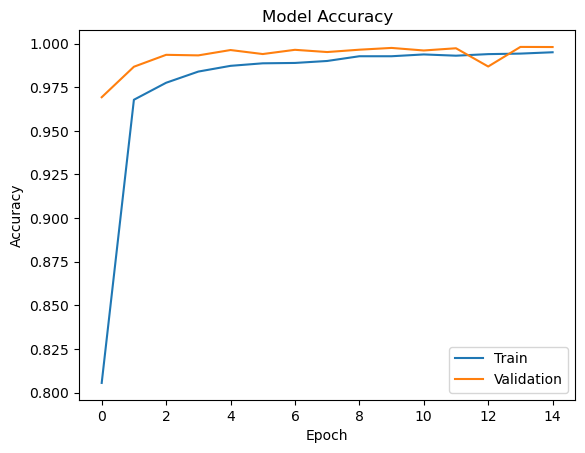

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Evaluate Final Accuracy

In [51]:
loss, accuracy = model.evaluate(val_data)
print("Final Validation Accuracy:", accuracy)

491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9980 - loss: 0.0076
Final Validation Accuracy: 0.9980233311653137


# Confusion Matrix

In [61]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━

# Plot Confusion Matrix

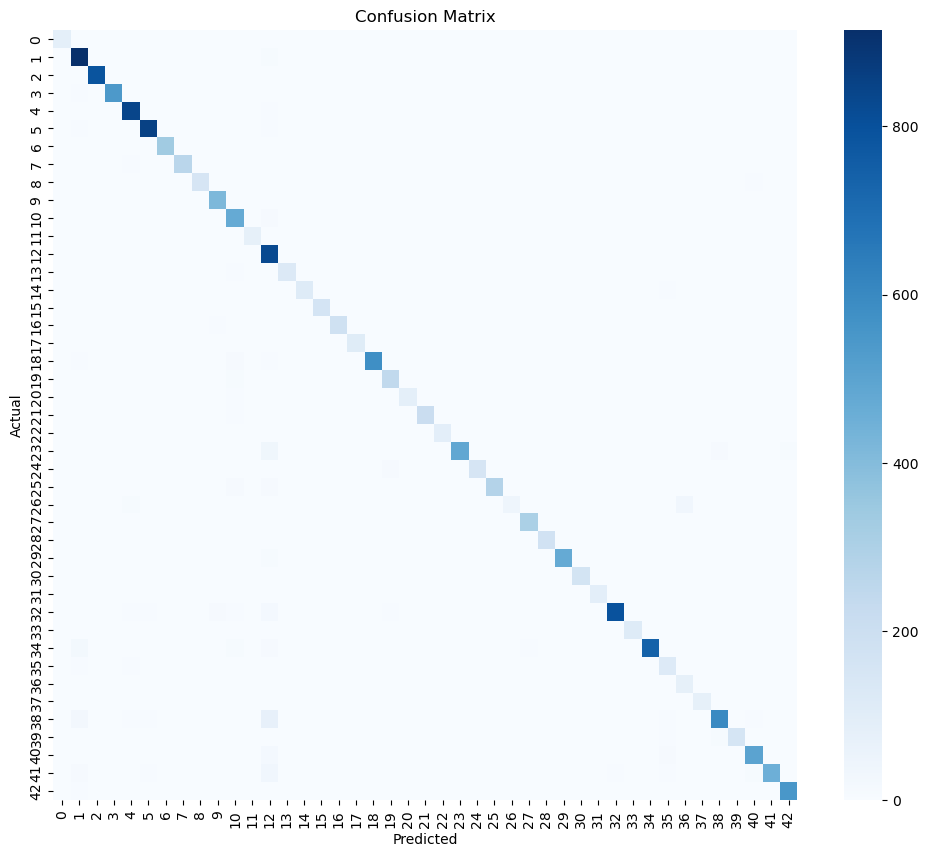

In [63]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [65]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        92
           1       0.90      0.99      0.94       923
           2       1.00      0.98      0.99       804
           3       0.99      0.98      0.98       555
           4       0.94      0.99      0.97       850
           5       0.96      0.98      0.97       872
           6       0.96      1.00      0.98       335
           7       1.00      0.96      0.98       272
           8       1.00      0.95      0.97       162
           9       0.95      1.00      0.97       415
          10       0.87      0.97      0.92       487
          11       1.00      1.00      1.00        82
          12       0.75      0.99      0.86       834
          13       1.00      0.94      0.97       136
          14       0.96      0.94      0.95       122
          15       0.99      0.99      0.99       163
          16       0.98      0.97      0.98       194
          17       1.00    

In [69]:
import os
print(os.listdir("Train/0")[:5])

['00000_00000_00000(1).png', '00000_00000_00000.png', '00000_00000_00001(1).png', '00000_00000_00001.png', '00000_00000_00002(1).png']


# Test Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


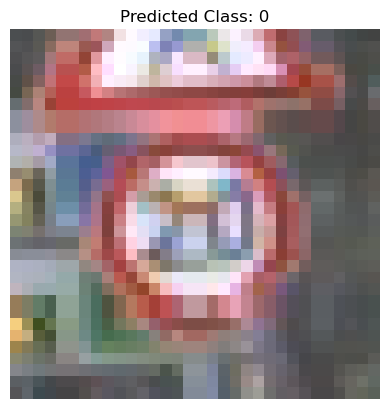

In [71]:
from tensorflow.keras.preprocessing import image

img_path = "Train/0/00000_00000_00000.png"

img = image.load_img(img_path, target_size=(32,32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class}")
plt.axis("off")
plt.show()

# Conclusion

#### This project successfully implemented a Convolutional Neural Network (CNN) to classify 43 traffic sign classes. The dataset contained over 78,000 images, and the model achieved approximately 99% validation accuracy. The model demonstrated strong performance with low loss and high precision, recall, and F1-score. It can also predict traffic signs from new input images effectively.